# Project: Investigate a Dataset - [TMDb movie data]

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction

### Dataset Description 

The dataset used for this analysis is the TMDb (The Movie Database) Movies Dataset, sourced from Kaggle as part of Udacity's "Investigate a Dataset" project. It contains metadata for approximately 10,000 films the columns are as follows :- 

### Column Descriptions

- **id** — Unique identifier for each movie
- **imdb_id** — Unique identifier linking to IMDb database
- **popularity** — TMDb community popularity score
- **budget** — Production budget of the movie in USD
- **revenue** — Box office gross revenue in USD
- **original_title** — Title of the movie as originally released
- **cast** — Pipe separated list of lead actors
- **homepage** — Official movie website URL
- **director** — Name of the movie director
- **tagline** — Official marketing tagline of the movie
- **keywords** — Pipe separated thematic keywords
- **overview** — Short plot synopsis of the movie
- **runtime** — Duration of the movie in minutes
- **genres** — Pipe separated list of movie genres
- **production_companies** — Pipe separated list of production studios
- **release_date** — Date the movie was theatrically released
- **vote_count** — Total number of user ratings on TMDb
- **vote_average** — Average user rating on a scale of 0 to 10
- **release_year** — Year the movie was released
- **budget_adj** — Budget adjusted to 2010 USD accounting for inflation
- **revenue_adj** — Revenue adjusted to 2010 USD accounting for inflation

### Question(s) for Analysis
Some of the questions for the analysis are :- 
1. Does more revenue mean higher ratings??
2. How has average movie runtime changed over the decades?


In [148]:
# import pandas for data manipulation
import pandas as pd
# import numpy for numerical operations
import numpy as np
# import matplotlib for data visualization
import matplotlib.pyplot as plt
#reusable function to add labels and title to every plot

def add_plot_labels(title, xlabel, ylabel):
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

<a id='wrangling'></a>
# Data Wrangling

### General Properties

The dataset was loaded and inspected for missing values, 
duplicate rows, and data types. The following issues were found:

- Several columns had missing values — homepage had 7930 missing, 
  tagline had 2824, cast had 76, and director had 44
- Budget and revenue columns had a large number of zero values 
  representing missing financial data
- release_date was stored as a string and needed to be converted 
  to datetime format
- One duplicate row was found and removed

In [149]:
# load the dataset from csv file into a dataframe
df=pd.read_csv('Database_TMDb_movie_data/tmdb-movies.csv')
# check dataframe structure, column names and datatypes
df.info()
# check how many null values exist in each column
print(df.isnull().sum())
# check how many duplicate rows exist
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10866 entries, 0 to 10865
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    10866 non-null  int64  
 1   imdb_id               10856 non-null  object 
 2   popularity            10866 non-null  float64
 3   budget                10866 non-null  int64  
 4   revenue               10866 non-null  int64  
 5   original_title        10866 non-null  object 
 6   cast                  10790 non-null  object 
 7   homepage              2936 non-null   object 
 8   director              10822 non-null  object 
 9   tagline               8042 non-null   object 
 10  keywords              9373 non-null   object 
 11  overview              10862 non-null  object 
 12  runtime               10866 non-null  int64  
 13  genres                10843 non-null  object 
 14  production_companies  9836 non-null   object 
 15  release_date       

1


### Data Cleaning

1. **Converted release_date** from string to datetime format to enable date operations

2. **Dropped irrelevant columns** — keywords, homepage, tagline, imdb_id, and overview 
   were removed because they are not needed for any of our analysis questions

3. **Dropped null rows** — rows where director, genres, cast, and production_companies 
   were null were removed because these columns are essential for analysis

4. **Removed duplicate rows** — to ensure no movie is counted more than once

5. **Created two dataframes:** 
  - df_clean — contains all 9773 movies, used for questions that do not need financial data
  - df_financial — contains only movies with valid non-zero budget and revenue, 
     used for questions that depend on financial data

6. **Zero values in budget and revenue** — were treated as missing data and removed 
   from df_financial because a budget or revenue of zero is not realistic

In [150]:
# convert release_date from string to datetime format for date operations
df.release_date=pd.to_datetime(df.release_date)
# drop columns not needed for analysis
df.drop(['keywords','homepage', 'tagline', 'imdb_id', 'overview'],axis=1,inplace=True,errors='ignore') 
# drop rows where important columns have null values
df.dropna(subset=['director', 'genres', 'cast', 'production_companies'], inplace=True) 
# remove duplicate rows
df.drop_duplicates(inplace=True) 
# verify no duplicates remain
df.duplicated().sum() 


0

In [151]:
# check distribution of budget values to identify zero values
print(df.budget.value_counts())
# check distribution of revenue values to identify zero values
print(df.revenue.value_counts())
# check distribution of adjusted budget values
df.budget_adj.value_counts()


0           4751
20000000     187
15000000     180
25000000     178
10000000     170
            ... 
10300000       1
7400000        1
17080000       1
27000          1
19000          1
Name: budget, Length: 533, dtype: int64
0            5022
12000000       10
10000000        8
6000000         6
2000000         6
             ... 
249348933       1
41227069        1
368744044       1
129000000       1
33736689        1
Name: revenue, Length: 4611, dtype: int64


0.000000e+00    4751
2.103337e+07      17
2.000000e+07      16
1.016400e+07      16
4.605455e+06      15
                ... 
2.988613e+07       1
1.222614e+07       1
3.939535e+07       1
6.520610e+07       1
1.276423e+05       1
Name: budget_adj, Length: 2549, dtype: int64

In [152]:
# create clean dataframe for non financial questions like genres and ratings
df_clean= df.copy()

df_clean.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 9772 entries, 0 to 10865
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9772 non-null   int64         
 1   popularity            9772 non-null   float64       
 2   budget                9772 non-null   int64         
 3   revenue               9772 non-null   int64         
 4   original_title        9772 non-null   object        
 5   cast                  9772 non-null   object        
 6   director              9772 non-null   object        
 7   runtime               9772 non-null   int64         
 8   genres                9772 non-null   object        
 9   production_companies  9772 non-null   object        
 10  release_date          9772 non-null   datetime64[ns]
 11  vote_count            9772 non-null   int64         
 12  vote_average          9772 non-null   float64       
 13  release_year     

In [153]:
# create financial dataframe with only movies that have valid budget and revenue data
# zeros represent missing data not actual zero values so we remove them
df_financial=df.query('budget != 0 and revenue != 0 and budget_adj !=0 and revenue_adj !=0' ).copy() 
df_financial.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 3805 entries, 0 to 10848
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    3805 non-null   int64         
 1   popularity            3805 non-null   float64       
 2   budget                3805 non-null   int64         
 3   revenue               3805 non-null   int64         
 4   original_title        3805 non-null   object        
 5   cast                  3805 non-null   object        
 6   director              3805 non-null   object        
 7   runtime               3805 non-null   int64         
 8   genres                3805 non-null   object        
 9   production_companies  3805 non-null   object        
 10  release_date          3805 non-null   datetime64[ns]
 11  vote_count            3805 non-null   int64         
 12  vote_average          3805 non-null   float64       
 13  release_year     

<a id='eda'></a>
# Exploratory Data Analysis:-



# Research Question 1 (Does more revenue mean higher ratings?)

## 1D Exploration — Vote Average Distribution
Before exploring the relationship between revenue and ratings, 
let us first understand each variable individually.
We will start by looking at the distribution of vote_average.

In [154]:
# get basic statistics of vote_average to understand its distribution
df_clean.vote_average.describe()

count    9772.000000
mean        5.963528
std         0.913174
min         1.500000
25%         5.400000
50%         6.000000
75%         6.600000
max         8.700000
Name: vote_average, dtype: float64

###  Observation from the statistics:- 

1. Mean rating is approximately 5.96 — so average movies score around 6 out of 10
2. 50% of movies fall between 5.4 and 6.6 (25th and 75th percentile)
3. Minimum rating is 1.5 and maximum is 8.7 — no movie scored a perfect 10
4. The std of 0.91 means ratings don't vary drastically

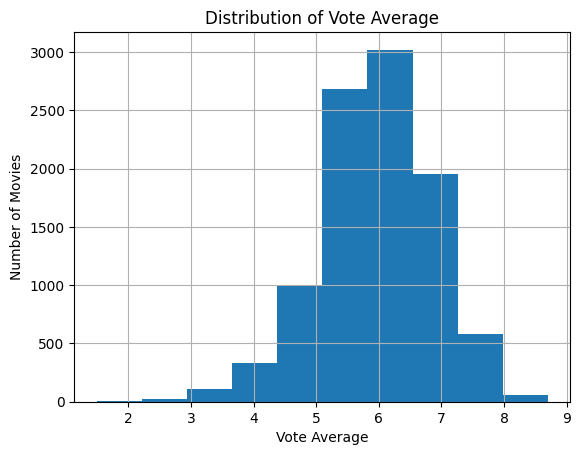

In [155]:
# plot histogram to visualize distribution of vote_average
df_clean.vote_average.hist()
add_plot_labels('Distribution of Vote Average', 'Vote Average', 'Number of Movies')


### Observation from the histogram:-

1. The distribution of vote_average is left skewed
2. The peak of the distribution is around 6.0, meaning most movies receive an average rating of 6 
3. There are very few movies with ratings below 3, these could be considered outliers

# 1D Exploration — Revenue_adj Distribution

Note:- df_clean was not suitable for revenue analysis because of the high number of zero values.


In [156]:
# get basic statistics of revenue_adj to understand its distribution
df_financial.revenue_adj.describe()


count    3.805000e+03
mean     1.387159e+08
std      2.169973e+08
min      2.370705e+00
25%      1.925371e+07
50%      6.284688e+07
75%      1.658054e+08
max      2.827124e+09
Name: revenue_adj, dtype: float64

### Observation from the statistics:- 

1. Count is 3805 — so df_financial has 3805 movies with valid revenue
2. Mean is 138 million dollars — average movie revenue
3. Median (50%) is 62 million dollars — half of movies earned less than this
4. Mean is much higher than median — confirms right skew, blockbusters are pulling the mean up
5. Max is 2.8 billion dollars — that's likely Avatar or a similar blockbuster, clear outlier


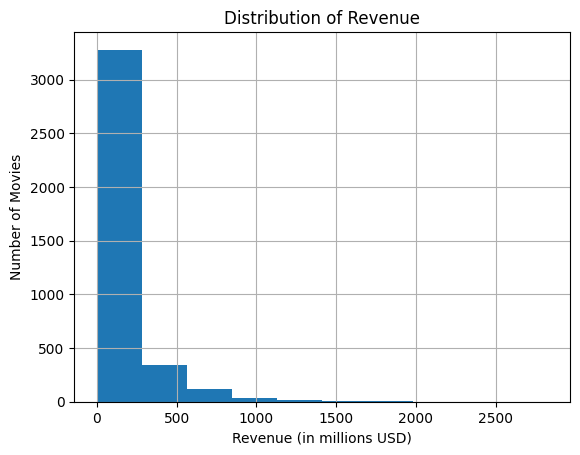

In [157]:
# convert revenue to millions for better readability on chart
df_financial['revenue_millions']=df_financial['revenue_adj']/1000000
# plot histogram to visualize distribution of revenue
df_financial.revenue_millions.hist()
add_plot_labels('Distribution of Revenue', 'Revenue (in millions USD)', 'Number of Movies')



### Observation - Revenue Distribution (df_financial)

- The distribution of revenue_adj is right skewed
- The x axis ranges from 0 to 2.5 billion dollars
- The first bar (0 to 250 million) is by far the tallest with 
  approximately 3300 movies — meaning the overwhelming majority 
  of movies earned less than 250 million dollars
- The mean is much higher than the median because a small number 
  of extremely high earning blockbusters are pulling the mean upward
- The maximum revenue is approximately 2.8 billion dollars which is likely 
  a blockbuster movie which is a clear outlier
- This tells us that the movie industry follows a long tail 
  distribution — a very small number of blockbusters earn enormous 
  amounts while the majority of movies earn modestly

# 2D Exploration — Vote_average & Revenue_adj Distribution

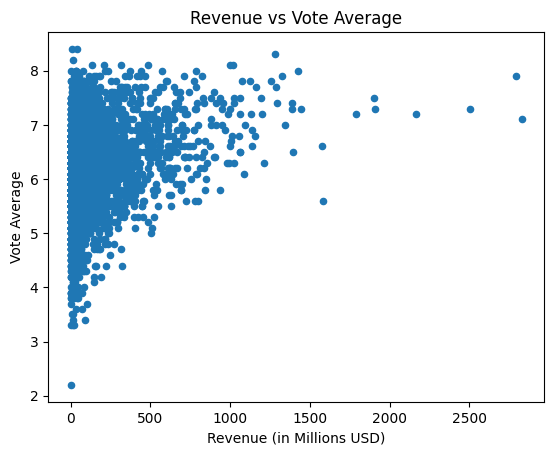

In [158]:
# scatter plot to explore relationship between revenue and vote average
df_financial.plot(kind='scatter', x='revenue_millions', y='vote_average')
add_plot_labels('Revenue vs Vote Average','Revenue (in Millions USD)', 'Vote Average')

### Observation from Vote_average & Revenue_adj Distribution

1. There is no strong relationship between revenue and ratings
2. Movies with low revenue are spread across all rating levels — from 2 to 8.7
3. The highest rated movie (close to 8.7) actually has very low revenue
4. The highest earning movie (~2.8B dollars) has a rating of only around 7-8 — not the highest
5. Most dots are clustered on the left regardless of their rating
6. This suggests that commercial success does not equal critical/audience success
7. **Limitation** :- This is called a weak or no correlation 

# Correlation statistic:-

   The correlation coefficient between revenue and vote average 
   is 0.27 — indicating a weak positive correlation. This means 
   higher revenue does not strongly predict higher ratings.
   We cannot conclude that revenue causes higher ratings.

In [159]:
# calculate correlation between revenue and vote average
# value between -1 and 1, closer to 0 means weak relationship
df_financial['revenue_adj'].corr(df_financial['vote_average'])

0.2682273354916279

# 2D Exploration — Vote Count vs Vote Average


Now let us explore whether movies with more votes tend to 
have higher ratings. vote_count represents how many people 
voted, while vote_average represents the rating they gave.

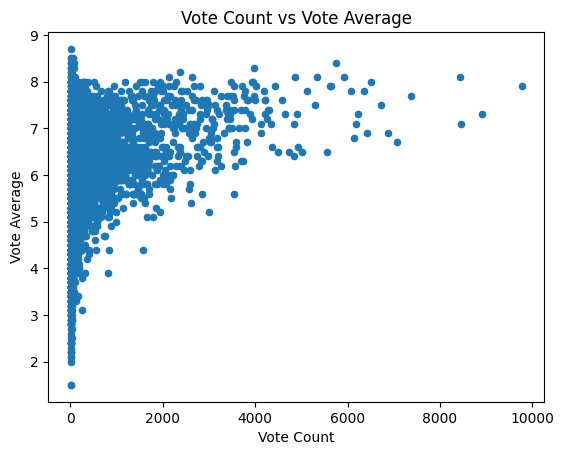

In [160]:
# scatter plot to explore relationship between vote_count and vote_average
df_clean.plot(kind='scatter', x='vote_count', y='vote_average')
add_plot_labels('Vote Count vs Vote Average', 'Vote Count', 'Vote Average')

### Observation from Vote Count vs Vote Average


- Most movies have a vote count below 1000, shown by the 
  heavy clustering on the left side of the chart
- There is no strong relationship between vote count and vote average
- Movies with very low vote counts show ratings spread across 
  all levels from 1.5 to 8.7 — meaning a small number of voters 
  can give very high or very low ratings
- Movies with high vote counts (above 5000) tend to cluster 
  between ratings of 6.5 to 8.5 — suggesting that when more 
  people vote, extreme ratings average out
- This is an important limitation — a movie with 10 votes and 
  a rating of 9.0 is less reliable than a movie with 5000 votes 
  and a rating of 7.5
- This confirms that vote count alone does not determine 
  how good a movie is

# Conclusion — Question 1: Does more revenue mean higher ratings?

Based on our analysis of three variables — revenue, vote average, 
and vote count — we can conclude that:

- Higher revenue does NOT strongly predict higher ratings
- The correlation coefficient of 0.27 confirms a weak positive 
  relationship between revenue and ratings
- The highest rated movies do not necessarily earn the most revenue
- The highest earning movies do not necessarily have the highest ratings
- Movies with more votes tend to have more stable and reliable ratings
  compared to movies with very few votes

## **Limitation:**
- This analysis cannot prove that revenue causes higher or lower ratings
- A correlation of 0.27 only shows a weak relationship, not causation
- Many movies in the dataset had zero budget and revenue values which 
  were removed, meaning our analysis only covers movies that reported 
  their financial data — this may not represent all movies equally
- Box office revenue does not include streaming, DVD sales or other 
  revenue sources which could change the results

## **Further Research:**
- It would be interesting to see if the relationship between revenue 
  and ratings has changed over the decades
- Including streaming revenue data could give a more complete picture

# Research Question 2  (How has average movie runtime changed over the decades?)



### 1D Exploration — Runtime Distribution
Before exploring runtime trends over time, let us first 
understand the distribution of runtime individually.

In [161]:
# get basic statistics of runtime to understand its distribution
df.runtime.describe()

count    9772.000000
mean      102.926627
std        27.877432
min         0.000000
25%        90.000000
50%       100.000000
75%       112.000000
max       877.000000
Name: runtime, dtype: float64

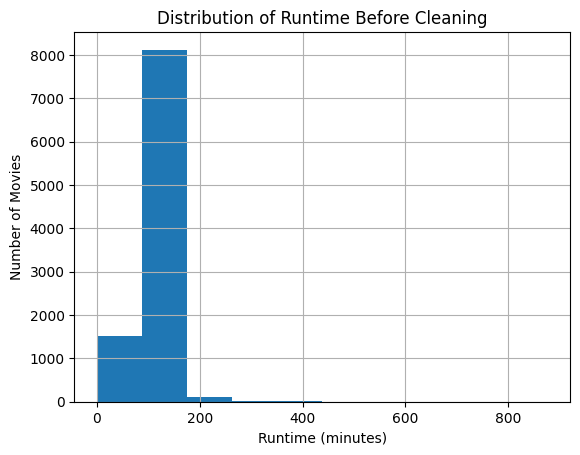

In [162]:
# plot histogram to visualize distribution of runtime
df.runtime.hist()
add_plot_labels('Distribution of Runtime Before Cleaning', 'Runtime (minutes)', 'Number of Movies')


In [163]:
# remove rows where runtime is 0 as it represents missing data
# verify runtime statistics after cleaning
df_clean = df_clean[(df_clean['runtime'] != 0)]
df_clean.runtime.describe()

count    9759.000000
mean      103.063736
std        27.641529
min         3.000000
25%        91.000000
50%       100.000000
75%       112.000000
max       877.000000
Name: runtime, dtype: float64

In [164]:
# remove movies with unrealistic runtime — less than 15 minutes or more than 300 minutes
# these are likely data entry errors not actual short films
# verify statistics after cleaning*
df_clean=df_clean[(df_clean['runtime'] >= 15) & (df_clean['runtime']<=300)]
df_clean.runtime.describe()

count    9663.000000
mean      103.301252
std        21.281876
min        15.000000
25%        91.000000
50%       100.000000
75%       112.000000
max       300.000000
Name: runtime, dtype: float64

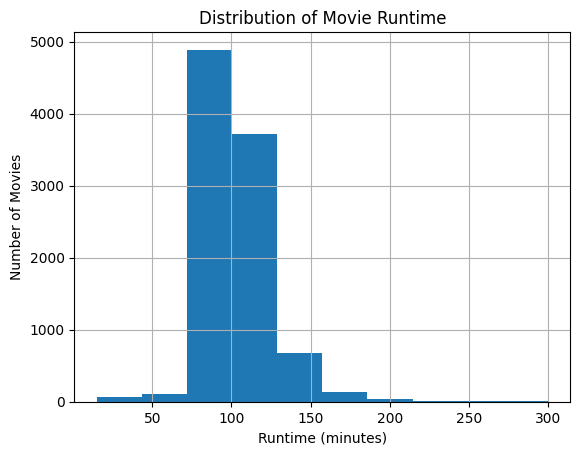

In [165]:
# plot histogram of cleaned runtime distribution
df_clean['runtime'].hist()
add_plot_labels('Distribution of Movie Runtime', 'Runtime (minutes)', 'Number of Movies')

### Observation — Runtime Distribution

- The distribution of runtime is right skewed
- The peak is between 80 and 100 minutes, meaning most movies 
  have a runtime of around 1.5 hours
- The mean runtime is approximately 103 minutes and the median 
  is 100 minutes — very close to each other confirming a 
  fairly symmetric distribution around 100 minutes
- 50% of movies fall between 91 and 112 minutes
- Runtimes below 15 minutes and above 300 minutes were removed 
  as they represented data entry errors or extreme outliers
- The maximum runtime after cleaning is 300 minutes — 5 hours, 
  which while long is not impossible for epic films
- This tells us the movie industry has a fairly standard runtime 
  of around 1.5 to 2 hours for most films

# 1D Exploration — Release Year Distribution

Now let us look at the distribution of release years 
to understand what time period our dataset covers.

In [166]:
# get basic statistics of release_year
# plot histogram of release_year distribution
df_clean.release_year.describe()

count    9663.000000
mean     2000.797682
std        13.065483
min      1960.000000
25%      1994.000000
50%      2005.000000
75%      2011.000000
max      2015.000000
Name: release_year, dtype: float64

###  Observation from the statistics:- 

1. Dataset covers 1960 to 2015 — 55 years of movies
2. Mean year is 2000 — dataset is skewed towards recent movies
3. 50% of movies were released after 2005 — majority are recent

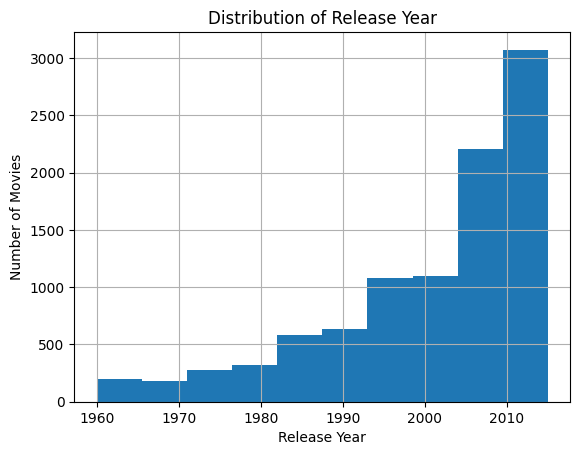

In [167]:
# plot histogram of release year distribution
df_clean.release_year.hist()
add_plot_labels('Distribution of Release Year', 'Release Year', 'Number of Movies')

### Observation — release_year


1. The distribution of release_year is left skewed
2. The dataset has significantly more recent movies than older ones
3. More than 50% of movies were released after 2005
4. Very few movies exist from the 1960s and 1970s
5. This is a limitation — our trend analysis may be more accurate for recent decades than older ones due to fewer data points

# 2D Exploration — runtime vs release_year


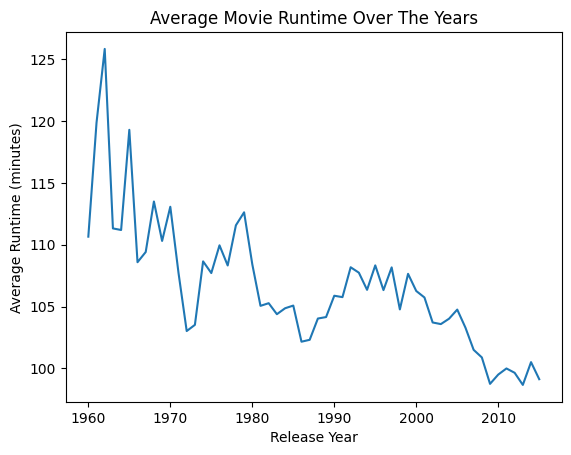

In [168]:
# group movies by release_year and calculate mean runtime for each year
# plot line chart to show runtime trend over time
df_clean.groupby('release_year')['runtime'].mean(numeric_only=True).plot(kind='line')
add_plot_labels('Average Movie Runtime Over The Years', 'Release Year', 'Average Runtime (minutes)')

### Observation — Average Runtime Over The Years

- There is a clear downward trend in average movie runtime 
  from 1960 to 2015
- In the early 1960s average runtime was around 125 minutes 
  — approximately 2 hours
- By 2015 average runtime had dropped to around 100 minutes 
  — approximately 1 hour 40 minutes
- This means movies have gotten approximately 25 minutes 
  shorter on average over 55 years
- There are some fluctuations — a notable peak around 1963 
  and another around 1979
- The most dramatic drop happens after 2010 where runtime 
  falls below 100 minutes consistently
- This could be due to changing audience preferences, 
  streaming platforms, or shorter attention spans in 
  modern audiences

**Limitation:**
- The dataset has very few movies from the 1960s compared 
  to recent years — so the average runtime for older decades 
  may not be fully representative

### 2D Exploration — Average Runtime by Decade
Instead of looking year by year, let us group movies into decades to see the runtime trend more clearly.

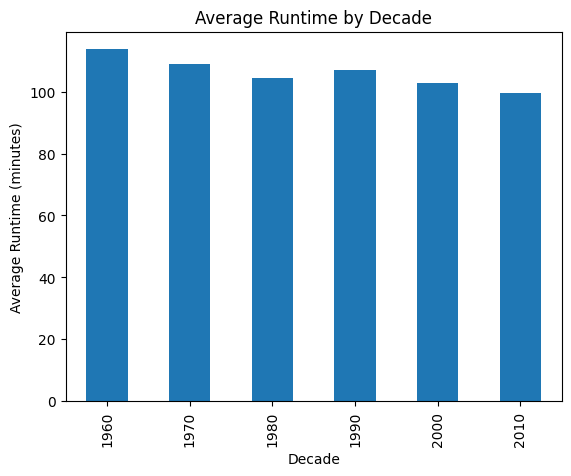

In [169]:
# create a new decade column by grouping release_year into decades
# group by decade and calculate mean runtime
# plot bar chart to compare average runtime across decades
df_clean['decade']=(df_clean['release_year'] //10)*10
df_clean.groupby('decade')['runtime'].mean(numeric_only=True).plot(kind='bar')
add_plot_labels('Average Runtime by Decade', 'Decade', 'Average Runtime (minutes)')


### Observation — Average Runtime by Decade

- The bar chart clearly confirms the downward trend in 
  average movie runtime across decades
- The 1960s had the longest average runtime at approximately 
  112 minutes
- The 2010s had the shortest average runtime at approximately 
  100 minutes
- Runtime has decreased consistently across every decade 
  with no exceptions
- The total drop from 1960s to 2010s is approximately 
  12 minutes
- The 1990s is a slight exception — runtime increased slightly 
  compared to the 1980s before dropping again in the 2000s
- This bar chart confirms what the line chart showed earlier 
  but in a cleaner and clearer way — movies have been getting 
  shorter over time
- The difference between decades is not dramatic — only about 
  2-3 minutes per decade on average

**Key Insight:**
- Both the line chart and bar chart tell the same story — 
  movie runtimes have been gradually decreasing over the decades
- Having two visualizations confirm the same trend makes 
  our conclusion more reliable

In [170]:
# calculate and print average runtime for each decade
df_clean.groupby('decade')['runtime'].mean().round(2)


decade
1960    113.62
1970    108.73
1980    104.38
1990    106.93
2000    102.66
2010     99.59
Name: runtime, dtype: float64

### Observation from the statistics:- 


1. Overall runtime decreased by approximately 14 minutes from 1960s to 2010s
2. The 1990s shows a slight increase of 2.55 minutes compared to 1980s — the only decade where runtime increased
3. The 2010s is the first decade where average runtime dropped below 100 minutes

# Conclusion — Question 2: How has average movie runtime changed over the decades?

 Based on our analysis of runtime, release_year, and decade we can conclude that:

- Average movie runtime has consistently decreased over the decades
- Movies in the 1960s averaged 113.62 minutes while movies 
  in the 2010s averaged only 99.59 minutes
- This is a decrease of approximately 14 minutes over 55 years
- The 2010s is the first decade where average runtime dropped 
  below 100 minutes
- The trend is confirmed by both the line chart and bar chart

**Limitation:**
- The dataset has significantly fewer movies from the 1960s 
  and 1970s compared to recent decades — so averages for 
  older decades may not be fully representative
- Runtime data had some errors — zero values and extreme 
  outliers like 877 minutes were removed before analysis
- We cannot conclude that audience preferences caused the 
  decrease in runtime — there could be other factors like 
  changes in filmmaking style, streaming platforms, or 
  studio decisions

**Further Research:**
- It would be interesting to see if runtime trends differ 
  across genres — do Action movies follow the same trend 
  as Comedy movies?
- Including data beyond 2015 would show if the trend 
  continues into the streaming era

<a id='conclusions'></a>

# Conclusions

### Summary of Findings

**Question 1 — Does more revenue mean higher ratings?**
- Our analysis found a weak positive correlation of 0.27 
  between revenue and ratings
- Higher revenue does not strongly predict higher ratings
- Commercial success and audience appreciation are not 
  strongly linked in the movie industry

**Question 2 — How has average movie runtime changed over the decades?**
- Average movie runtime has consistently decreased from 
  113.62 minutes in the 1960s to 99.59 minutes in the 2010s
- This is a decrease of approximately 14 minutes over 55 years
- The 2010s is the first decade where average runtime 
  dropped below 100 minutes

### Overall Limitations
- The dataset only covers movies up to 2015 — trends may 
  have changed significantly with the rise of streaming platforms
- Many movies had zero budget and revenue values which were 
  removed — our financial analysis only covers movies that 
  reported their data publicly
- We cannot imply causation from any correlations found — 
  all relationships observed are associative only
- The dataset has significantly more recent movies than older 
  ones which may bias trend analysis for older decades

### Further Research
- Including data beyond 2015 would show how streaming has 
  affected both revenue patterns and movie runtimes
- Analyzing runtime trends by genre would give more specific insights
- Including streaming revenue, DVD sales and other sources 
  would give a more complete picture of financial success


In [171]:
# Running this cell will execute a bash command to convert this notebook to an .html file
!python -m nbconvert --to html Investigate_a_Dataset_Ayush.ipynb

[NbConvertApp] Converting notebook Investigate_a_Dataset_Ayush.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 9 image(s).
[NbConvertApp] Writing 653917 bytes to Investigate_a_Dataset_Ayush.html
